In [46]:
# It is a supervised learning model
# ========================
# Train to learn following mapping:
# Noisy distribution  --->  Ideal distribution

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError

import numpy as np
from itertools import product
import torch
import torch.nn as nn
# from torch.optim import optimizer
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

def build_circuit_4q(thetas):
    qc = QuantumCircuit(4, 4)
    
    for i in range(4):
        qc.ry(thetas[i], i)
    
    qc.measure([0,1,2,3], [0,1,2,3])
    return qc

def counts_to_probs_4q(counts):
    probs = np.zeros(16)
    
    for bitstring, count in counts.items():
        idx = int(bitstring, 2)
        probs[idx] = count
        
    probs = probs / np.sum(probs)
    return probs

def get_ideal_4q(thetas, shots=4096):
    qc = build_circuit_4q(thetas)
    result = ideal_sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    return counts_to_probs_4q(counts)

def get_noisy_4q(thetas, shots=4096):
    qc = build_circuit_4q(thetas)
    result = noisy_sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    return counts_to_probs_4q(counts)

noise_model = NoiseModel()

readout_error = ReadoutError([
    [0.90, 0.10],
    [0.15, 0.85]
])

# اعمال روی هر 4 کیوبیت
for q in range(4):
    noise_model.add_readout_error(readout_error, [q])

ideal_sim = AerSimulator()
noisy_sim = AerSimulator(noise_model=noise_model)

def generate_dataset_4q(num_samples=5000):
    
    X = []
    Y = []
    
    for _ in range(num_samples):
        thetas = np.random.uniform(0, np.pi, size=4)
        
        p_ideal = get_ideal_4q(thetas)
        p_noisy = get_noisy_4q(thetas)
        
        X.append(p_noisy)
        Y.append(p_ideal)
    
    return np.array(X), np.array(Y)

class MLP_4Q(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            
            nn.Linear(128, 256),
            nn.ReLU(),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            
            nn.Linear(128, 16),
            nn.Softmax(dim=1)
        )
    
    def forward(self, x):
        return self.net(x)

X, Y = generate_dataset_4q(5000)

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

dataset = TensorDataset(X_tensor, Y_tensor)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

model = MLP_4Q()

criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 71
loss_history = []

for epoch in range(epochs):
    total_loss = 0
    
    for x_batch, y_batch in train_loader:
        
        optimizer.zero_grad()
        
        preds = model(x_batch)
        loss = criterion(torch.log(preds + 1e-8), y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    if (epoch % 5)==0:
        print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")

Epoch 0, Loss: 0.784759
Epoch 5, Loss: 0.046438
Epoch 10, Loss: 0.037700
Epoch 15, Loss: 0.027657
Epoch 20, Loss: 0.016207
Epoch 25, Loss: 0.012192
Epoch 30, Loss: 0.011045
Epoch 35, Loss: 0.010250
Epoch 40, Loss: 0.009407
Epoch 45, Loss: 0.009570
Epoch 50, Loss: 0.009086
Epoch 55, Loss: 0.008823
Epoch 60, Loss: 0.008331
Epoch 65, Loss: 0.008776
Epoch 70, Loss: 0.008390


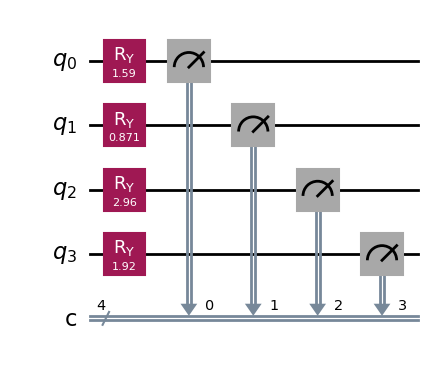

In [47]:
# Circuit
thetas = np.random.uniform(0, np.pi, 4)  # thetas =  [1.2, 2.2, 3, 1]
qc = build_circuit_4q(thetas)
# رسم مدار
qc.draw("mpl")

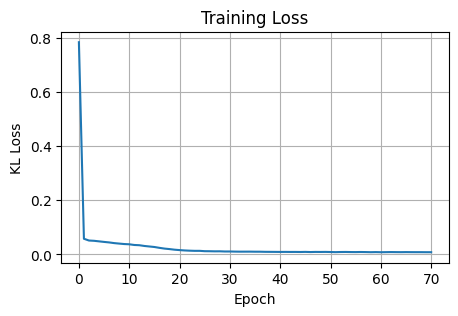

In [48]:
def kl_divergence(p, q):
    return np.sum(p * np.log((p + 1e-10) / (q + 1e-10)))
# DKL (P∥Q)=∑_i P(i) log Q(i)/P(i)
def fidelity(p, q):
    return (np.sum(np.sqrt(p * q)))**2

def l1_error(p, q):
    return np.sum(np.abs(p - q))

import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.title("Training Loss")
plt.grid()
plt.show()

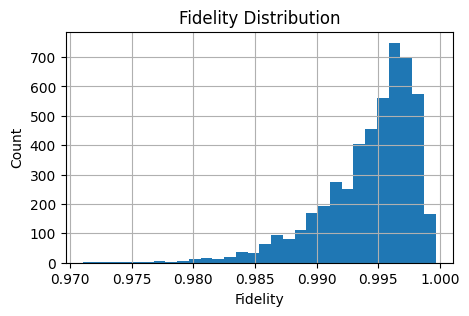

In [49]:
fidelities = []
l1_errors = []
kl_values = []

model.eval()

with torch.no_grad():
    for i in range(len(X)):
        x = torch.tensor(X[i], dtype=torch.float32).unsqueeze(0)
        pred = model(x).numpy().flatten()
        true = Y[i]

        fidelities.append(fidelity(true, pred))
        l1_errors.append(l1_error(true, pred))
        kl_values.append(kl_divergence(true, pred))

plt.figure(figsize=(5,3))
plt.hist(fidelities, bins=30)
# plt.hist(l1_errors, bins=30)
plt.xlabel("Fidelity")
plt.ylabel("Count")
plt.title("Fidelity Distribution")
plt.grid()
plt.show()

In [17]:
# plt.hist(l1_errors, bins=30)
# plt.xlabel("L1 Error")
# plt.ylabel("Count")
# plt.title("L1 Error Distribution")
# plt.grid()
# plt.show()

In [21]:
# plt.hist(kl_values, bins=30)
# plt.xlabel("KL Divergence")
# plt.ylabel("Count")
# plt.title("KL Divergence Distribution")
# plt.grid()
# plt.show()
# print(len(X[1]))

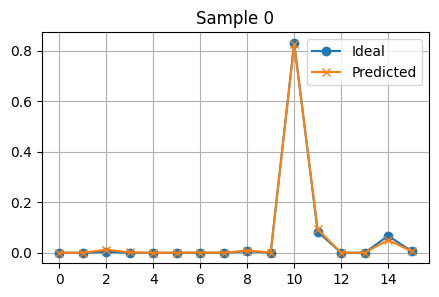

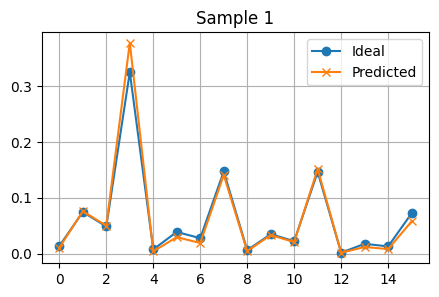

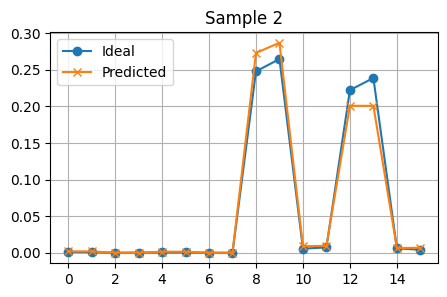

In [50]:
for i in range(3):
    x = torch.tensor(X[i], dtype=torch.float32).unsqueeze(0)
    pred = model(x).detach().numpy().flatten()
    true = Y[i]

    plt.figure(figsize=(5,3))
    plt.plot(true, label="Ideal", marker='o')
    plt.plot(pred, label="Predicted", marker='x')
    plt.title(f"Sample {i}")
    plt.legend()
    plt.grid()
    plt.show()

In [23]:
# plt.scatter(fidelities, l1_errors, alpha=0.5)
# plt.xlabel("Fidelity")
# plt.ylabel("L1 Error")
# plt.title("Fidelity vs L1 Error")
# plt.grid()
# plt.show()

In [51]:
print("===== BASELINE METRICS =====")
print("Average Fidelity:", np.mean(fidelities))
print("Std Fidelity:", np.std(fidelities))

print("Average L1 Error:", np.mean(l1_errors))
print("Average KL:", np.mean(kl_values))

===== BASELINE METRICS =====
Average Fidelity: 0.9942743059166436
Std Fidelity: 0.0038128659461457216
Average L1 Error: 0.08182068099057507
Average KL: 0.009741827302003927


## Split Test and Train

In [6]:
# ================================
# IMPORTS
# ================================
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split

In [7]:
# ================================
# METRICS
# ================================
def kl_divergence(p, q):
    return np.sum(p * np.log((p + 1e-10) / (q + 1e-10)))

def fidelity(p, q):
    return (np.sum(np.sqrt(p * q)))**2

def l1_error(p, q):
    return np.sum(np.abs(p - q))

In [8]:
# ================================
# CIRCUIT
# ================================
def build_circuit_4q(thetas):
    qc = QuantumCircuit(4, 4)
    for i in range(4):
        qc.ry(thetas[i], i)
    qc.measure([0,1,2,3], [0,1,2,3])
    return qc

def counts_to_probs_4q(counts):
    probs = np.zeros(16)
    for bitstring, count in counts.items():
        idx = int(bitstring, 2)
        probs[idx] = count
    return probs / np.sum(probs)

In [9]:
# ================================
# NOISE MODEL BUILDER
# ================================
def create_noise_model(p01, p10):
    noise_model = NoiseModel()
    readout_error = ReadoutError([[1-p01, p01],
                                 [p10, 1-p10]])
    for q in range(4):
        noise_model.add_readout_error(readout_error, [q])
    return noise_model

In [10]:
# ================================
# SIMULATORS
# ================================
ideal_sim = AerSimulator()

def get_probs(thetas, noise_model=None, shots=4096):
    qc = build_circuit_4q(thetas)
    sim = AerSimulator(noise_model=noise_model)
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    return counts_to_probs_4q(counts)

In [11]:
# ================================
# DATA GENERATION
# ================================
def generate_dataset(num_samples, theta_range, noise_range):
    X = []
    Y = []
    Theta = []

    for _ in range(num_samples):
        # Generate 4 random angles 
        thetas = np.random.uniform(theta_range[0], theta_range[1], size=4)

        p01 = np.random.uniform(noise_range[0], noise_range[1])
        p10 = np.random.uniform(noise_range[0], noise_range[1])

        noise_model = create_noise_model(p01, p10)

        p_ideal = get_probs(thetas, noise_model=None)
        p_noisy = get_probs(thetas, noise_model=noise_model)

        X.append(p_noisy)
        Y.append(p_ideal)
        Theta.append(thetas)

    return np.array(X), np.array(Y), np.array(Theta)
# theta_range = (0, np.pi)
# noise_range = (0.01, 0.02)
# a, b , tet= generate_dataset(500, theta_range, noise_range)
# print(tet[0])

In [12]:
# ================================
# MODEL
# ================================
class MLP_4Q(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 16),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.net(x)

In [13]:
# ================================
# GENERATE TRAIN / TEST DATA
# ================================
print("Generating TRAIN dataset...")
X_train, Y_train, theta_train = generate_dataset(
    num_samples=4000,
    theta_range=(0, np.pi),           # train distribution  ##### check    !!!!!!
    noise_range=(0.05, 0.15)          # train noise    ##### check    !!!!!!
)  

##### check    !!!!!! At the moment I set both similar!
print("Generating TEST dataset...")
X_test, Y_test, theta_test = generate_dataset(
    num_samples=1000,
    theta_range=(0, np.pi),         # different theta distribution? -- set similar 
    noise_range=(0.05, 0.15)          # different noise?  -- set similar
)
print("Generating dataset completed!")
# ================================
# DATA LOADERS
# ================================
train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(Y_train, dtype=torch.float32)
    ),
    batch_size=64,
    shuffle=True
)

Generating TRAIN dataset...
Generating TEST dataset...
Generating dataset completed!


In [14]:
# ================================
# TRAINING
# ================================
model_mlp = MLP_4Q()
criterion = nn.KLDivLoss(reduction="batchmean")
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3)

epochs = 51
train_losses = []
test_losses = []

for epoch in range(epochs):
    model_mlp.train()
    total_loss = 0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()

        preds = model_mlp(x_batch)
        loss = criterion(torch.log(preds + 1e-8), y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # --- TEST ---
    model_mlp.eval()
    with torch.no_grad():
        preds_test = model_mlp(torch.tensor(X_test, dtype=torch.float32))
        test_loss = criterion(
            torch.log(preds_test + 1e-8),
            torch.tensor(Y_test, dtype=torch.float32)
        ).item()

    test_losses.append(test_loss)
    if (epoch % 5 )== 0:
        print(f"Epoch {epoch}: Train={train_loss:.5f}, Test={test_loss:.5f}")

Epoch 0: Train=0.94661, Test=0.29093
Epoch 5: Train=0.05425, Test=0.05059
Epoch 10: Train=0.04016, Test=0.03753
Epoch 15: Train=0.03110, Test=0.02950
Epoch 20: Train=0.02771, Test=0.02707
Epoch 25: Train=0.02672, Test=0.03691
Epoch 30: Train=0.02589, Test=0.02634
Epoch 35: Train=0.02565, Test=0.02751
Epoch 40: Train=0.02525, Test=0.02712
Epoch 45: Train=0.02504, Test=0.02664
Epoch 50: Train=0.02612, Test=0.02910


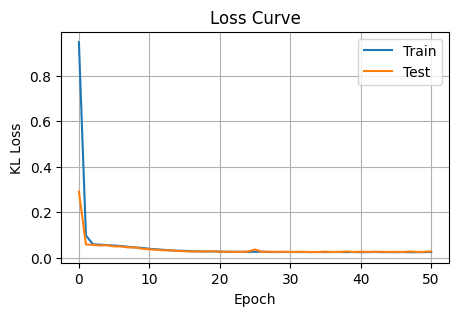

In [15]:
# ================================
# PLOT LOSS
# ================================
plt.figure(figsize=(5,3))
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.grid()
plt.show()

In [16]:
# ================================
# EVALUATION METRICS
# ================================
fidelities = []
l1_errors = []
kl_values = []

model_mlp.eval()

with torch.no_grad():
    for i in range(len(X_test)):
        pred = model_mlp(torch.tensor(X_test[i], dtype=torch.float32).unsqueeze(0)).numpy().flatten()
        true = Y_test[i]

        fidelities.append(fidelity(true, pred))
        l1_errors.append(l1_error(true, pred))
        kl_values.append(kl_divergence(true, pred))

print("\n===== TEST METRICS =====")
print("Avg Fidelity:", np.mean(fidelities))
print("Avg L1:", np.mean(l1_errors))
print("Avg KL:", np.mean(kl_values))   # for diff test dist Avg Fidelity: 0.939528763007786


===== TEST METRICS =====
Avg Fidelity: 0.9837324064461074
Avg L1: 0.13809841311437607
Avg KL: 0.02910245177467476


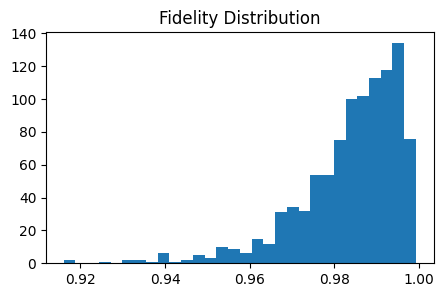

In [17]:
# ================================
# HISTOGRAMS
# ================================
plt.figure(figsize=(5,3))
plt.hist(fidelities, bins=30)
plt.title("Fidelity Distribution")
plt.show()

# plt.hist(l1_errors, bins=30)
# plt.title("L1 Error Distribution")
# plt.show()


In [18]:
# # ================================
# # VISUAL COMPARISON (RANDOM TEST)
# # ================================
# indices = np.random.choice(len(X_test), 3, replace=False)

# for idx in indices:
#     pred = model_mlp(torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0)).detach().numpy().flatten()
#     true = Y_test[idx]

#     plt.figure(figsize=(9,3))
#     x_axis = np.arange(16)

#     plt.bar(x_axis - 0.2, true, width=0.4, label="Ideal")
#     plt.bar(x_axis + 0.2, pred, width=0.4, label="Predicted")

#     f = fidelity(true, pred)
#     plt.title(f"Test Sample {idx} | Fidelity={f:.4f}")
#     plt.legend()
#     plt.grid()
#     plt.show()
#     # دیتاست برای حالت های با صفر بیشتر احتمال رخ دادن بیشتری دارد یعنی 
#     #P(0):|0000> > P(1):|1111>    
#     # dataset: intrinsically biased

In [19]:
# import numpy as np

# model_mlp.eval()

# indices = np.random.choice(len(X_test), 3, replace=False)

# for idx in indices:
#     x = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0)
#     pred = model_mlp(x).detach().numpy().flatten()
#     true = Y_test[idx]

#     plt.figure(figsize=(5,3))
#     plt.plot(true, label="Ideal", marker='o')
#     plt.plot(pred, label="Predicted", marker='x')
#     plt.title(f"Test Sample {idx}")
#     plt.xlabel("State Index (0–15)")
#     plt.ylabel("Probability")
#     plt.legend()
#     plt.grid()
#     plt.show()

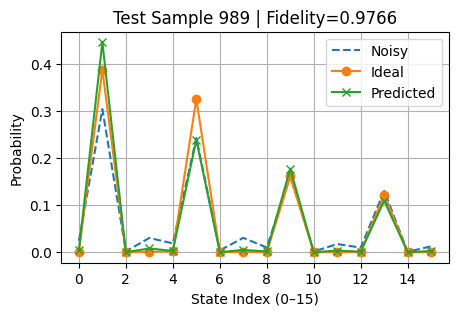

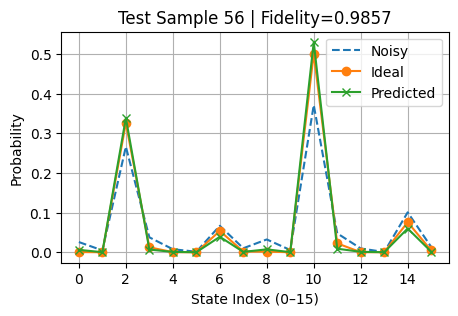

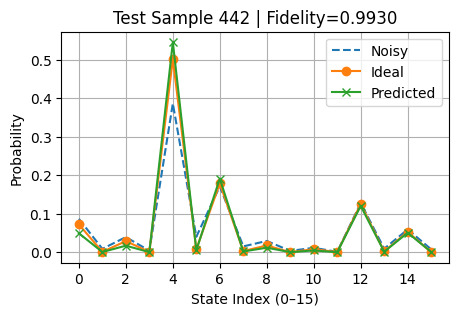

In [34]:
def fidelity(p, q):
    return (np.sum(np.sqrt(p * q)))**2

model_mlp.eval()

indices = np.random.choice(len(X_test), 3, replace=False)

for idx in indices:
    x = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0)
    pred = model_mlp(x).detach().numpy().flatten()
    true = Y_test[idx]
    x_noise = X_test[idx]
    f = fidelity(true, pred)

    plt.figure(figsize=(5,3))
    plt.plot(x_noise, '--' , label="Noisy")
    plt.plot(true, label="Ideal", marker='o')
    plt.plot(pred, label="Predicted", marker='x')
    plt.title(f"Test Sample {idx} | Fidelity={f:.4f}")
    plt.xlabel("State Index (0–15)")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid()
    plt.show()

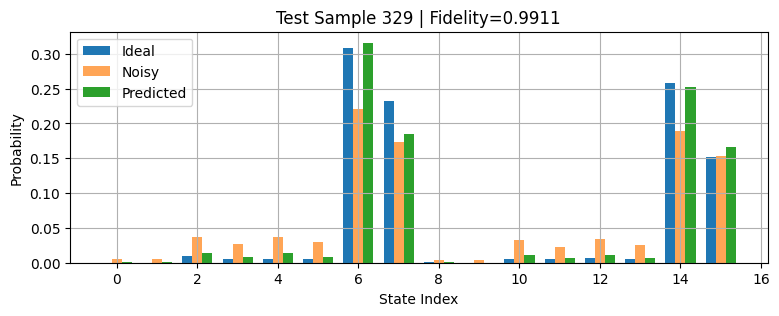

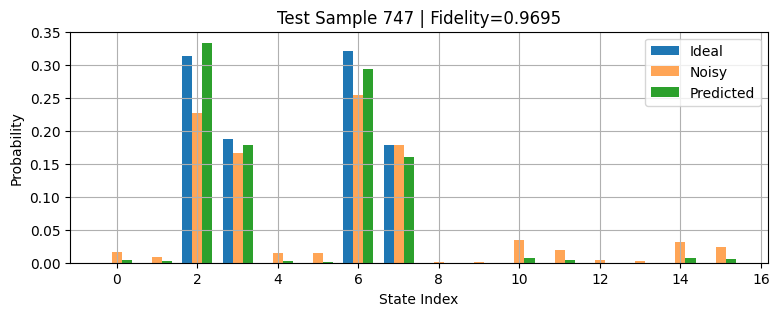

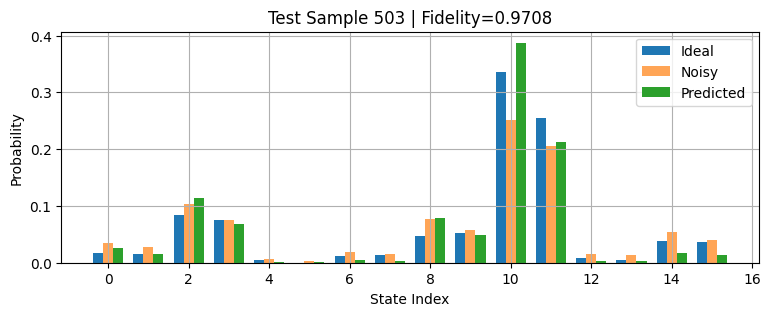

In [37]:
# ================================
# VISUAL COMPARISON (RANDOM TEST)
# ================================
model_mlp.eval()

indices = np.random.choice(len(X_test), 3, replace=False)

for idx in indices:
    x = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0)
    pred = model_mlp(x).detach().numpy().flatten()
    true = Y_test[idx]
    x_noise = X_test[idx]
    
    f = fidelity(true, pred)

    x_axis = np.arange(16)

    plt.figure(figsize=(9,3))

    plt.bar(x_axis - 0.25, true, width=0.25, label="Ideal")
    plt.bar(x_axis , x_noise, width=0.25, label="Noisy", alpha = 0.7)
    plt.bar(x_axis+ 0.25 , pred, width=0.25, label="Predicted")
    
    plt.title(f"Test Sample {idx} | Fidelity={f:.4f}")
    plt.xlabel("State Index")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid()
    plt.show()

#     # دیتاست برای حالت های با صفر بیشتر احتمال رخ دادن بیشتری دارد یعنی 
#     #P(0):|0000> > P(1):|1111>    
#     # dataset: intrinsically biased

### رسم نمودارهای خط برحست زاویه
نشون می ده که مدل در چه ناحیه کوانتمی خوب/بد عمل می کنه


In [38]:
theta_mean_list = []
kl_list = []
fidelity_list = []

model_mlp.eval()
with torch.no_grad():
    for i in range(len(X_test)):
        
        x = torch.tensor(X_test[i], dtype=torch.float32).unsqueeze(0)
        pred = model_mlp(x).numpy().flatten()
        true = Y_test[i]

        # θ مربوط به همین sample (از generator باید ذخیره شده باشد)
        # فرض: theta_test داریم
        theta_mean = np.mean(theta_test[i])

        theta_mean_list.append(theta_mean)

        # metrics
        kl = np.sum(true * np.log((true + 1e-10) / (pred + 1e-10)))
        fid = (np.sum(np.sqrt(true * pred)))**2

        kl_list.append(kl)
        fidelity_list.append(fid)

In [40]:
kl_list = np.array(kl_list)
error_list = kl_list  # یا 1 - fidelity

theta_mean_list = np.array(theta_mean_list)
kl_list = np.array(kl_list)
fidelity_list = np.array(fidelity_list)

sorted_idx = np.argsort(theta_mean_list)

theta_sorted = theta_mean_list[sorted_idx]
kl_sorted = kl_list[sorted_idx]
fid_sorted = fidelity_list[sorted_idx]

In [41]:
# import matplotlib.pyplot as plt

# plt.figure()
# plt.scatter(theta_sorted, kl_sorted, alpha=0.5)

# plt.xlabel("Mean θ")
# plt.ylabel("KL Divergence")
# plt.title("Error (KL) vs θ")
# plt.grid()
# plt.show()

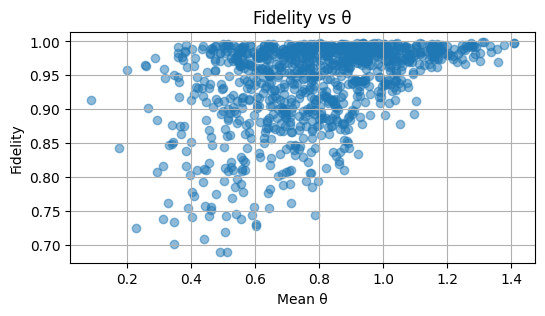

In [89]:
plt.figure(figsize=(6,3))
plt.scatter(theta_sorted, fid_sorted, alpha=0.5)

plt.xlabel("Mean θ")
plt.ylabel("Fidelity")
plt.title("Fidelity vs θ")
plt.grid()
plt.show()

In [42]:
bins = np.linspace(0, np.pi, 20)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

kl_binned = []
fid_binned = []

for i in range(len(bins)-1):
    mask = (theta_sorted >= bins[i]) & (theta_sorted < bins[i+1])
    
    kl_binned.append(np.mean(kl_sorted[mask]) if np.any(mask) else np.nan)
    fid_binned.append(np.mean(fid_sorted[mask]) if np.any(mask) else np.nan)

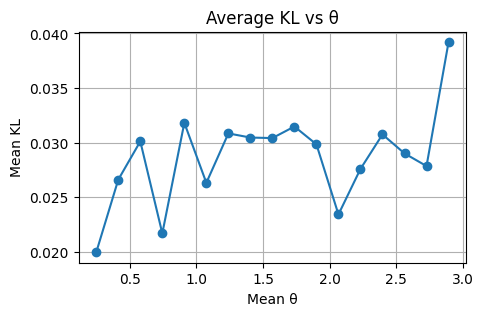

In [43]:
plt.figure(figsize=(5,3))
plt.plot(bin_centers, kl_binned, marker='o')

plt.xlabel("Mean θ")
plt.ylabel("Mean KL")
plt.title("Average KL vs θ")
plt.grid()
plt.show()

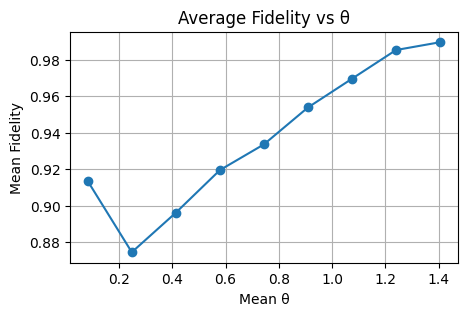

In [86]:
plt.figure(figsize=(5,3))
plt.plot(bin_centers, fid_binned, marker='o')

plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Average Fidelity vs θ")
plt.grid()
plt.show()

In [ ]:
#خطای بازسازی فقط تابع نویز نیست، بلکه تابع حالت کوانتومی (زاویه) هم هست.
# |0⟩ → RY(θ) → measurement
# نتیجه گیری:
#  خطای خطای خوانش در فضای احتمال غیرخطی است
# پس خطا خوانش به توزیع تابع ورودی وابسته است و نویز اثر غیر خطی دارد 
# پس باید مدلی داشته باشیم که به حالت حساس باشد
# noise depends on state distribution

مدل در واقع داره معکوس یک ماتریس تقریباً ثابت رو یاد می‌گیره.

noise ثابت است
کل dataset با یک "قانون ثابت" تولید شده
پس مدل فقط همون قانون رو یاد می‌گیره

## Next Target- physics informed

یادگیری صریح (explicit) ماتریس نویز با constraint فیزیکی

NN → M

p_noisy ≈ M @ p_ideal

M=M1 ⊗M2 ⊗M3 ⊗M4 

Mi =[1−ϵi      ϵi ]
    [δi      1−δi ]

به جای 256 پارامتر حالا هشت پارامتر رو یاد می گیره
[ε1, δ1, ε2, δ2, ε3, δ3, ε4, δ4]

این در واقع ترکیب هر دو گزینه‌ هست:

 - noise matrix learning 

 - physics-informed model

داده را با نویز متغیر تولید می‌کند
یک شبکه می‌سازد که ۸ پارامتر فیزیکی 

(ϵi,δi) 

را یاد می‌گیرد
از آن‌ها ماتریس نویز 

M

را با 

Kronecker product

می‌سازد
با قیدهای فیزیکی 

(non-negative, column-stochastic)

کار می‌کند با 

KL(p_noisy || M·p_ideal)

آموزش می‌بیند بعد از آموزش، می‌تواند 

M^−1

 را برای 
 
mitigation

استفاده کند

M @ p_ideal ≈ p_noisy

بعد از آموزش:

p_ideal ≈ M^{-1} @ p_noisy

Assumption:
noise = tensor product of single-qubit channels

مدل دو مرحله ای هست

p_noisy (16-dim) → (ε₁, δ₁, ..., ε₄, δ₄)

مرحله دوم

(ε, δ) → M₁ ⊗ M₂ ⊗ M₃ ⊗ M₄

مرحله سوم

p_pred = M @ p_ideal


In [90]:
# =========================================
# IMPORTS
# =========================================
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# =========================================
# DEVICE / DTYPE
# =========================================
device = torch.device("cpu")
DTYPE = torch.float64

In [91]:
# =========================================
# METRICS
# =========================================
def kl_divergence_np(p, q):
    return np.sum(p * np.log((p + 1e-12) / (q + 1e-12)))

def fidelity_np(p, q):
    return (np.sum(np.sqrt(p * q)))**2

def l1_error_np(p, q):
    return np.sum(np.abs(p - q))

# =========================================
# QUANTUM CIRCUIT
# =========================================
def build_circuit_4q(thetas):
    qc = QuantumCircuit(4, 4)
    for i in range(4):
        qc.ry(thetas[i], i)
    qc.measure([0,1,2,3], [0,1,2,3])
    return qc

def counts_to_probs_4q(counts):
    probs = np.zeros(16)
    for bitstring, count in counts.items():
        idx = int(bitstring, 2)
        probs[idx] = count
    probs = probs / np.sum(probs)
    return probs

# =========================================
# NOISE MODEL (qiskit side)
# =========================================
def create_noise_model(p01, p10):
    noise_model = NoiseModel()
    readout_error = ReadoutError([[1-p01, p01],
                                 [p10, 1-p10]])
    for q in range(4):
        noise_model.add_readout_error(readout_error, [q])
    return noise_model

ideal_sim = AerSimulator()

def get_probs(thetas, noise_model=None, shots=4096):
    qc = build_circuit_4q(thetas)
    sim = AerSimulator(noise_model=noise_model)
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    return counts_to_probs_4q(counts)

In [92]:
# =========================================
# DATA GENERATION (with theta + noise logging)
# =========================================
def generate_dataset(num_samples, theta_range, noise_range):
    X = []   # noisy
    Y = []   # ideal
    Theta = []
    NoiseParams = []  # (p01, p10) per sample (for reference)

    for _ in range(num_samples):
        thetas = np.random.uniform(theta_range[0], theta_range[1], size=4)

        p01 = np.random.uniform(noise_range[0], noise_range[1])
        p10 = np.random.uniform(noise_range[0], noise_range[1])

        noise_model = create_noise_model(p01, p10)

        p_ideal = get_probs(thetas, noise_model=None)
        p_noisy = get_probs(thetas, noise_model=noise_model)

        X.append(p_noisy)
        Y.append(p_ideal)
        Theta.append(thetas)
        NoiseParams.append([p01, p10])

    return np.array(X), np.array(Y), np.array(Theta), np.array(NoiseParams)


In [93]:
# =========================================
# PHYSICS-INFORMED MODEL
# NN -> (eps_i, delta_i) for i=1..4
# Build M = kron(M1, M2, M3, M4)
# =========================================

def build_single_qubit_M(eps, delta):
    # shape (2,2)
    # [[1-eps, eps],
    #  [delta, 1-delta]]
    M = torch.stack([
        torch.stack([1.0 - eps, eps]),
        torch.stack([delta, 1.0 - delta])
    ])
    return M

def kron4(A, B, C, D):
    return torch.kron(torch.kron(torch.kron(A, B), C), D)

def normalize_columns(M):
    # ensure column-stochastic
    col_sum = M.sum(dim=0, keepdim=True) + 1e-12
    return M / col_sum

class NoiseModelNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.Sigmoid()  # eps, delta in (0,1)
        )

    def forward(self, x):
        # x: (batch, 16)
        params = self.net(x)  # (batch, 8)

        M_batch = []
        for p in params:
            Ms = []
            for i in range(4):
                eps = p[2*i]
                delta = p[2*i + 1]
                Mi = build_single_qubit_M(eps, delta)
                Ms.append(Mi)

            M_full = kron4(Ms[0], Ms[1], Ms[2], Ms[3])  # (16,16)
            M_full = normalize_columns(M_full)
            M_batch.append(M_full)

        M_batch = torch.stack(M_batch)  # (batch, 16, 16)
        return M_batch, params  # return params for inspection

def apply_noise(M, p_ideal):
    # p_ideal: (16,) ; M: (16,16)
    out = torch.matmul(M, p_ideal.unsqueeze(-1)).squeeze(-1)
    # numerical safety: re-normalize
    out = torch.clamp(out, min=1e-12)
    out = out / out.sum()
    return out

In [94]:
# =========================================
# GENERATE TRAIN / TEST (distribution shift)
# =========================================
print("Generating TRAIN dataset...")
X_train, Y_train, theta_train, noise_train = generate_dataset(
    num_samples=3000,
    theta_range=(0, np.pi),
    noise_range=(0.05, 0.15))

print("Generating TEST dataset...")
X_test, Y_test, theta_test, noise_test = generate_dataset(
    num_samples=800,
    theta_range=(0, np.pi/2),
    noise_range=(0.10, 0.25))
print("Generating datasets completed!")

Generating TRAIN dataset...
Generating TEST dataset...
Generating datasets completed!


In [95]:
 # =========================================
# DATA LOADERS
# =========================================
train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train, dtype=DTYPE),
        torch.tensor(Y_train, dtype=DTYPE)
    ),
    batch_size=64,
    shuffle=True
)

# =========================================
# TRAINING
# Loss: KL(p_noisy || M @ p_ideal)
# =========================================
model_phys = NoiseModelNN().to(device).to(DTYPE)
optimizer = optim.Adam(model_phys.parameters(), lr=1e-3)

def kl_torch(p, q):
    # both (batch, 16)
    return torch.sum(p * torch.log((p + 1e-12) / (q + 1e-12)), dim=1).mean()

epochs = 70
train_losses = []
test_losses = []

for epoch in range(epochs):
    model_phys.train()
    total_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        M_batch, _ = model_phys(x_batch)  # (batch,16,16)

        preds = []
        for i in range(len(x_batch)):
            pred = apply_noise(M_batch[i], y_batch[i])
            preds.append(pred)
        preds = torch.stack(preds)  # (batch,16)

        # target is x_batch (noisy)
        loss = kl_torch(x_batch, preds)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---- TEST ----
    model_phys.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_test, dtype=DTYPE)
        Y_t = torch.tensor(Y_test, dtype=DTYPE)

        M_batch, _ = model_phys(X_t)

        preds = []
        for i in range(len(X_t)):
            pred = apply_noise(M_batch[i], Y_t[i])
            preds.append(pred)
        preds = torch.stack(preds)

        test_loss = kl_torch(X_t, preds).item()
        test_losses.append(test_loss)
    if (epoch % 5)==0:
        print(f"Epoch {epoch}: Train={train_loss:.5f}, Test={test_loss:.5f}")


Epoch 0: Train=0.55111, Test=0.19799
Epoch 5: Train=0.01133, Test=0.05891
Epoch 10: Train=0.01122, Test=0.05951
Epoch 15: Train=0.01117, Test=0.06002
Epoch 20: Train=0.01107, Test=0.06155
Epoch 25: Train=0.01096, Test=0.05696
Epoch 30: Train=0.01082, Test=0.05274
Epoch 35: Train=0.01073, Test=0.05416
Epoch 40: Train=0.01059, Test=0.05413
Epoch 45: Train=0.01050, Test=0.04558
Epoch 50: Train=0.01036, Test=0.05049
Epoch 55: Train=0.01024, Test=0.04836
Epoch 60: Train=0.01017, Test=0.04166
Epoch 65: Train=0.00998, Test=0.04665


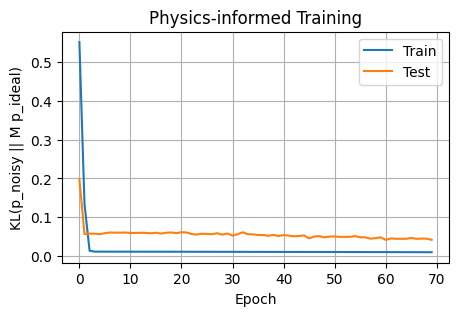

In [96]:
# =========================================
# LOSS PLOT
# =========================================
plt.figure(figsize=(5,3))
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("KL(p_noisy || M p_ideal)")
plt.title("Physics-informed Training")
plt.legend()
plt.grid()
plt.show()

In [97]:
# =========================================
# EVALUATION (Mitigation via inverse)
# p_ideal_hat ≈ M^{-1} @ p_noisy
# =========================================
fidelities = []
l1_errors = []
kl_values = []

model_phys.eval()
with torch.no_grad():
    for i in range(len(X_test)):
        x = torch.tensor(X_test[i], dtype=DTYPE)
        y_true = Y_test[i]

        M, params = model_phys(x.unsqueeze(0))
        M = M[0].cpu().numpy()

        # inverse (with regularization)
        M_reg = M + 1e-6 * np.eye(16)
        M_inv = np.linalg.inv(M_reg)

        p_est = M_inv @ x.numpy()
        p_est = np.clip(p_est, 1e-12, None)
        p_est = p_est / np.sum(p_est)

        fidelities.append(fidelity_np(y_true, p_est))
        l1_errors.append(l1_error_np(y_true, p_est))
        kl_values.append(kl_divergence_np(y_true, p_est))

print("\n===== MITIGATION METRICS (TEST) =====")
print("Avg Fidelity:", np.mean(fidelities))
print("Avg L1:", np.mean(l1_errors))
print("Avg KL:", np.mean(kl_values))


===== MITIGATION METRICS (TEST) =====
Avg Fidelity: 0.9194947183921909
Avg L1: 0.3266563668111245
Avg KL: 0.13633709001354463


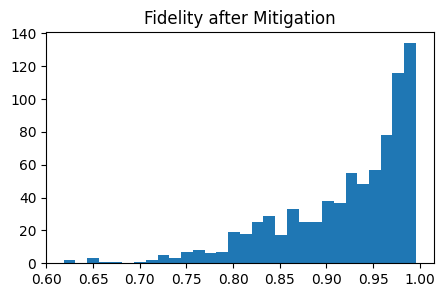

In [98]:
# =========================================
# HISTOGRAMS
# =========================================
plt.figure(figsize=(5,3))
plt.hist(fidelities, bins=30)
plt.title("Fidelity after Mitigation")
plt.show()

# plt.hist(l1_errors, bins=30)
# plt.title("L1 Error after Mitigation")
# plt.show()

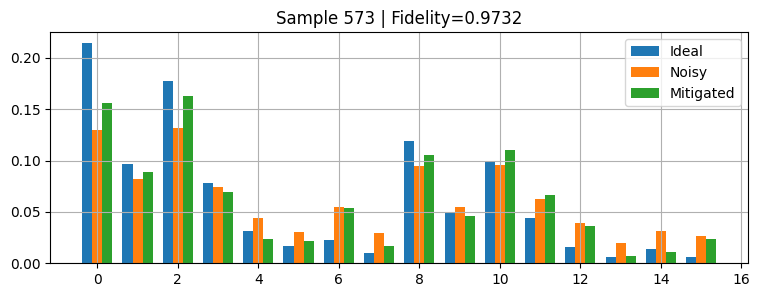

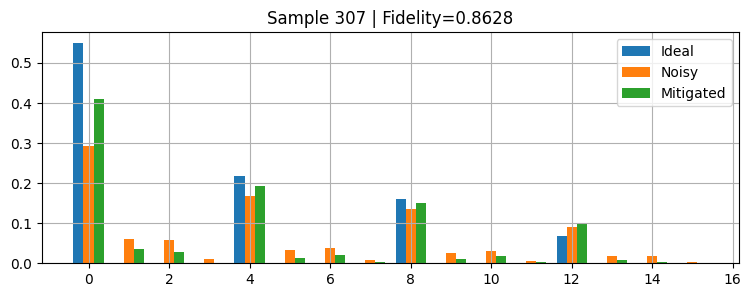

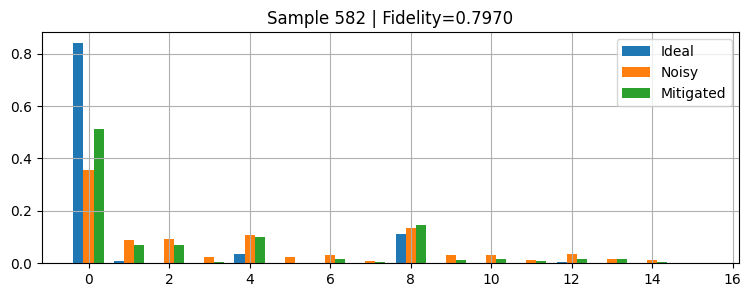

In [100]:
# =========================================
# VISUAL COMPARISON
# =========================================
idxs = np.random.choice(len(X_test), 3, replace=False)

for idx in idxs:
    x = torch.tensor(X_test[idx], dtype=DTYPE)
    y_true = Y_test[idx]

    M, _ = model_phys(x.unsqueeze(0))
    M = M[0].detach().cpu().numpy()

    M_inv = np.linalg.inv(M + 1e-6*np.eye(16))
    p_est = M_inv @ x.numpy()
    p_est = np.clip(p_est, 1e-12, None)
    p_est = p_est / np.sum(p_est)

    x_axis = np.arange(16)

    plt.figure(figsize=(9,3))
    plt.bar(x_axis - 0.25, y_true, width=0.25, label="Ideal")
    plt.bar(x_axis, x.numpy(), width=0.25, label="Noisy")
    plt.bar(x_axis + 0.25, p_est, width=0.25, label="Mitigated")

    f = fidelity_np(y_true, p_est)
    plt.title(f"Sample {idx} | Fidelity={f:.4f}")
    plt.legend()
    plt.grid()
    plt.show()

In [101]:
mlp_preds = []
phys_preds = []

model_mlp.eval()
model_phys.eval()

with torch.no_grad():
    for i in range(len(X_test)):
        
        x = torch.tensor(X_test[i], dtype=torch.float64)

        # -------- MLP --------
        pred_mlp = model_mlp(x.float().unsqueeze(0)).cpu().numpy().flatten()
        mlp_preds.append(pred_mlp)

        # -------- Physics-informed --------
        M, _ = model_phys(x.unsqueeze(0))
        M = M[0].detach().cpu().numpy()

        M_inv = np.linalg.inv(M + 1e-6*np.eye(16))

        p_est = M_inv @ x.numpy()
        p_est = np.clip(p_est, 1e-12, None)
        p_est = p_est / np.sum(p_est)

        phys_preds.append(p_est)

mlp_preds = np.array(mlp_preds)
phys_preds = np.array(phys_preds)

In [102]:
def compute_metrics(preds, Y):
    fidelities = []
    l1s = []
    kls = []

    for i in range(len(preds)):
        p = preds[i]
        y = Y[i]

        fidelities.append((np.sum(np.sqrt(p*y)))**2)
        l1s.append(np.sum(np.abs(p - y)))
        kls.append(np.sum(y * np.log((y+1e-10)/(p+1e-10))))

    return np.mean(fidelities), np.mean(l1s), np.mean(kls)

In [ ]:
### model comprison

In [103]:
f_mlp, l1_mlp, kl_mlp = compute_metrics(mlp_preds, Y_test)
f_phys, l1_phys, kl_phys = compute_metrics(phys_preds, Y_test)

print("\n===== COMPARISON =====")
print(f"{'Model':<20} {'Fidelity':<10} {'L1':<10} {'KL':<10}")
print("-"*50)
print(f"{'MLP':<20} {f_mlp:<10.4f} {l1_mlp:<10.4f} {kl_mlp:<10.4f}")
print(f"{'Physics-informed':<20} {f_phys:<10.4f} {l1_phys:<10.4f} {kl_phys:<10.4f}")


===== COMPARISON =====
Model                Fidelity   L1         KL        
--------------------------------------------------
MLP                  0.9340     0.2892     0.1006    
Physics-informed     0.9195     0.3267     0.1340    


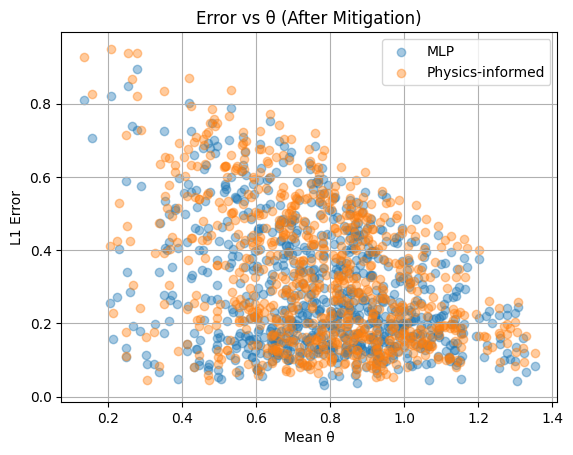

In [104]:
theta_mean = np.mean(theta_test, axis=1)

def compute_error_vs_theta(preds, Y):
    errors = []
    for i in range(len(preds)):
        errors.append(np.sum(np.abs(preds[i] - Y[i])))
    return np.array(errors)

err_mlp = compute_error_vs_theta(mlp_preds, Y_test)
err_phys = compute_error_vs_theta(phys_preds, Y_test)

# sort
idx = np.argsort(theta_mean)

theta_sorted = theta_mean[idx]
err_mlp_sorted = err_mlp[idx]
err_phys_sorted = err_phys[idx]

plt.figure()

plt.scatter(theta_sorted, err_mlp_sorted, alpha=0.4, label="MLP")
plt.scatter(theta_sorted, err_phys_sorted, alpha=0.4, label="Physics-informed")

plt.xlabel("Mean θ")
plt.ylabel("L1 Error")
plt.title("Error vs θ (After Mitigation)")
plt.legend()
plt.grid()
plt.show()

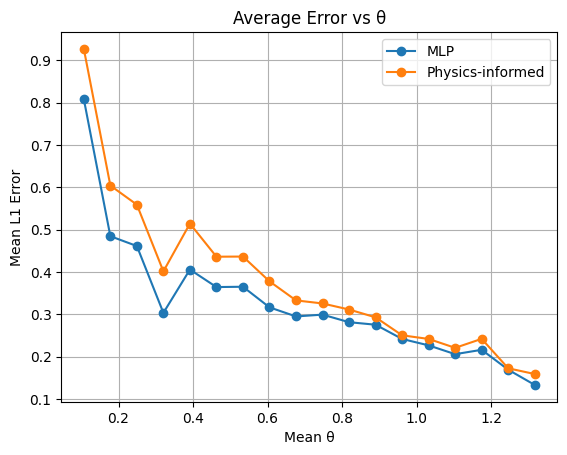

In [105]:
bins = np.linspace(0, np.max(theta_mean), 20)
centers = 0.5*(bins[:-1] + bins[1:])

def bin_avg(theta, err):
    out = []
    for i in range(len(bins)-1):
        mask = (theta >= bins[i]) & (theta < bins[i+1])
        out.append(np.mean(err[mask]) if np.any(mask) else np.nan)
    return out

mlp_binned = bin_avg(theta_mean, err_mlp)
phys_binned = bin_avg(theta_mean, err_phys)

plt.figure()
plt.plot(centers, mlp_binned, marker='o', label="MLP")
plt.plot(centers, phys_binned, marker='o', label="Physics-informed")

plt.xlabel("Mean θ")
plt.ylabel("Mean L1 Error")
plt.title("Average Error vs θ")
plt.legend()
plt.grid()
plt.show()

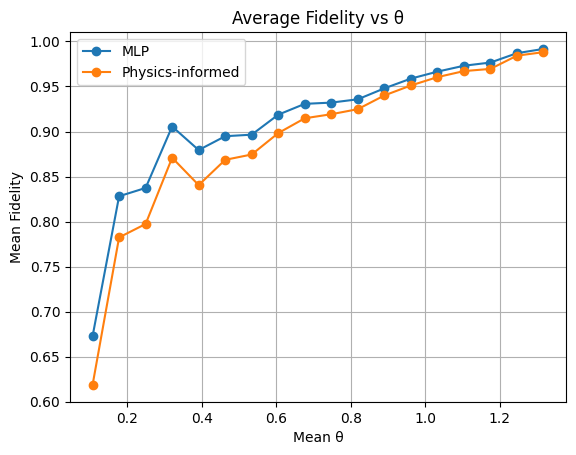

In [106]:
def compute_fidelity_list(preds, Y):
    fids = []
    for i in range(len(preds)):
        p = preds[i]
        y = Y[i]
        f = (np.sum(np.sqrt(p * y)))**2
        fids.append(f)
    return np.array(fids)

fid_mlp = compute_fidelity_list(mlp_preds, Y_test)
fid_phys = compute_fidelity_list(phys_preds, Y_test)

theta_mean = np.mean(theta_test, axis=1)

idx = np.argsort(theta_mean)

theta_sorted = theta_mean[idx]
fid_mlp_sorted = fid_mlp[idx]
fid_phys_sorted = fid_phys[idx]

bins = np.linspace(0, np.max(theta_mean), 20)
centers = 0.5 * (bins[:-1] + bins[1:])

def bin_avg(theta, values):
    out = []
    for i in range(len(bins)-1):
        mask = (theta >= bins[i]) & (theta < bins[i+1])
        out.append(np.mean(values[mask]) if np.any(mask) else np.nan)
    return out

fid_mlp_binned = bin_avg(theta_mean, fid_mlp)
fid_phys_binned = bin_avg(theta_mean, fid_phys)

plt.figure()

plt.plot(centers, fid_mlp_binned, marker='o', label="MLP")
plt.plot(centers, fid_phys_binned, marker='o', label="Physics-informed")

plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Average Fidelity vs θ")
plt.legend()
plt.grid()
plt.show()

## ZZ coupling

برهمکنش بین کیوبیت ها
به جای:

M=M1⊗M2⊗M3⊗M4


می‌سازیم:

M=Mlocal +αMinteraction 

Zi​Zj​∼bitsi​⋅bitsj​

[ q0q1, q0q2, q0q3, q1q2, q1q3, q2q3 ]

KL(p_ideal || M p_ideal)


In [108]:
def compute_zz_features(bit_index, n_qubits=4):
    # bit_index: 0..15
    bits = np.array(list(np.binary_repr(bit_index, width=n_qubits))).astype(int)
    
    zz = []
    for i in range(n_qubits):
        for j in range(i+1, n_qubits):
            zz.append(bits[i] * bits[j])
    return np.array(zz)  # size = 6

In [109]:
import torch.nn.functional as F

class ZZInteractionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # local noise (8 params → same as before)
        self.local_net = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 8),
            nn.Sigmoid()
        )
        
        # interaction correction (ZZ)
        self.zz_net = nn.Sequential(
            nn.Linear(6*16, 256),   # 6 fitures for every state
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.Tanh()
        )

    def build_local_M(self, p):  # همان مدل قبلی
        Ms = []
        for i in range(4):
            eps = p[2*i]
            delta = p[2*i+1]

            Mi = torch.stack([
                torch.stack([1-eps, eps]),
                torch.stack([delta, 1-delta])
            ])
            Ms.append(Mi)

        M_local = torch.kron(torch.kron(torch.kron(Ms[0], Ms[1]), Ms[2]), Ms[3])
        return M_local

    def forward(self, x):
        batch = x.shape[0]

        local_params = self.local_net(x)

        M_batch = []

        for b in range(batch):

            # --- local part ---
            M_local = self.build_local_M(local_params[b])

            # --- ZZ part ---
            zz_feat = []
            for i in range(16):
                zz_feat.append(compute_zz_features(i))

            zz_feat = torch.tensor(np.stack(zz_feat), dtype=torch.float32).flatten()
            corr = self.zz_net(zz_feat).view(16,16)
            # residual correction
            alpha = 0.05
            M = M_local + alpha * corr
            # normalize columns
            M = torch.abs(M)
            M = M / (M.sum(dim=0, keepdim=True) + 1e-12)

            M_batch.append(M)

        return torch.stack(M_batch)

In [110]:
def kl_loss(p, q):
    return torch.mean(torch.sum(p * torch.log((p+1e-12)/(q+1e-12)), dim=1))

In [111]:
model_zz = ZZInteractionModel()
optimizer = optim.Adam(model_zz.parameters(), lr=1e-3)

model_zz = model_zz.float()
epochs = 50

for epoch in range(epochs):
    total = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.float()
        y_batch = y_batch.float()
        
        optimizer.zero_grad()
        

        M_batch = model_zz(x_batch)

        preds = []

        for i in range(len(x_batch)):
            p = torch.matmul(M_batch[i], y_batch[i].unsqueeze(-1)).squeeze(-1)
            p = p / (p.sum() + 1e-12)
            preds.append(p)

        preds = torch.stack(preds)

        loss = kl_loss(x_batch, preds)

        loss.backward()
        optimizer.step()

        total += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total/len(train_loader):.5f}")

Epoch 1 | Loss: 0.27163
Epoch 2 | Loss: 0.11762
Epoch 3 | Loss: 0.05168
Epoch 4 | Loss: 0.03675
Epoch 5 | Loss: 0.02919
Epoch 6 | Loss: 0.02250
Epoch 7 | Loss: 0.01857
Epoch 8 | Loss: 0.01703
Epoch 9 | Loss: 0.01706
Epoch 10 | Loss: 0.01591
Epoch 11 | Loss: 0.01573
Epoch 12 | Loss: 0.01557
Epoch 13 | Loss: 0.01530
Epoch 14 | Loss: 0.01530
Epoch 15 | Loss: 0.01494
Epoch 16 | Loss: 0.01482
Epoch 17 | Loss: 0.01487
Epoch 18 | Loss: 0.01449
Epoch 19 | Loss: 0.01446
Epoch 20 | Loss: 0.01439
Epoch 21 | Loss: 0.01435
Epoch 22 | Loss: 0.01417
Epoch 23 | Loss: 0.01407
Epoch 24 | Loss: 0.01407
Epoch 25 | Loss: 0.01399
Epoch 26 | Loss: 0.01382
Epoch 27 | Loss: 0.01381
Epoch 28 | Loss: 0.01374
Epoch 29 | Loss: 0.01360
Epoch 30 | Loss: 0.01367
Epoch 31 | Loss: 0.01360
Epoch 32 | Loss: 0.01382
Epoch 33 | Loss: 0.01327
Epoch 34 | Loss: 0.01335
Epoch 35 | Loss: 0.01313
Epoch 36 | Loss: 0.01288
Epoch 37 | Loss: 0.01268
Epoch 38 | Loss: 0.01257
Epoch 39 | Loss: 0.01262
Epoch 40 | Loss: 0.01227
Epoch 41 

### metric evaluation

In [92]:
def evaluate(preds, Y):
    fid, l1, kl = [], [], []

    for i in range(len(preds)):
        p = preds[i]
        y = Y[i]

        fid.append((np.sum(np.sqrt(p*y)))**2)
        l1.append(np.sum(np.abs(p-y)))
        kl.append(np.sum(y*np.log((y+1e-12)/(p+1e-12))))

    return np.mean(fid), np.mean(l1), np.mean(kl)

def run_model(model, X, Y):
    preds = []

    model.eval()

    with torch.no_grad():
        for i in range(len(X)):
            x = torch.tensor(X[i], dtype=torch.float32).unsqueeze(0)

            M = model(x)[0]

            p = torch.matmul(
                M,
                torch.tensor(Y[i], dtype=torch.float32).unsqueeze(-1)
            ).squeeze(-1)

            p = p.detach().cpu().numpy()   # مهم
            p = np.clip(p, 1e-12, None)
            p = p / np.sum(p)

            preds.append(p)

    return np.array(preds)
zz_preds = run_model(model_zz, X_test, Y_test)
# MLP results (already have)
# phys results (old)
# zz results

In [93]:
f1,l1_1,kl1 = evaluate(mlp_preds, Y_test)
f2,l1_2,kl2 = evaluate(phys_preds, Y_test)
f3,l1_3,kl3 = evaluate(zz_preds, Y_test)
# f3,l1_3,kl3 = evaluate(model_zz, Y_test)


print("\n===== MODEL COMPARISON =====")
print("Model        Fidelity   L1        KL")
print("--------------------------------------")
print(f"MLP          {f1:.4f}     {l1_1:.4f}   {kl1:.4f}")
print(f"Physics      {f2:.4f}     {l1_2:.4f}   {kl2:.4f}")
print(f"Physics+ZZ   {f3:.4f}     {l1_3:.4f}   {kl3:.4f}")


===== MODEL COMPARISON =====
Model        Fidelity   L1        KL
--------------------------------------
MLP          0.9273     0.3091   0.1128
Physics      0.9249     0.3114   0.1318
Physics+ZZ   0.9146     0.3573   0.1282


### error vs θ

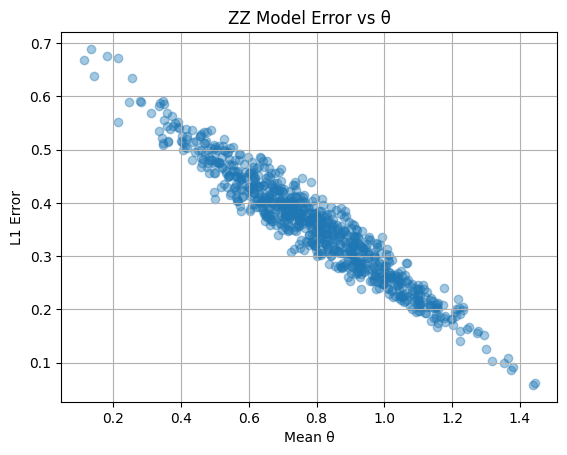

In [94]:
theta_mean = np.mean(theta_test, axis=1)

err_zz = np.array([np.sum(np.abs(p - y)) for p,y in zip(zz_preds, Y_test)])

idx = np.argsort(theta_mean)

plt.scatter(theta_mean[idx], err_zz[idx], alpha=0.4)
plt.xlabel("Mean θ")
plt.ylabel("L1 Error")
plt.title("ZZ Model Error vs θ")
plt.grid()
plt.show()

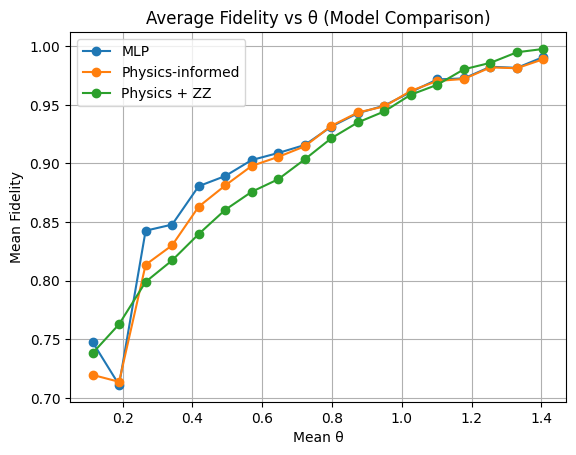

In [97]:
def compute_fidelity_list(preds, Y):
    fids = []
    for i in range(len(preds)):
        p = preds[i]
        y = Y[i]
        f = (np.sum(np.sqrt(p * y)))**2
        fids.append(f)
    return np.array(fids)

fid_mlp = compute_fidelity_list(mlp_preds, Y_test)
fid_phys = compute_fidelity_list(phys_preds, Y_test)
fid_zz = compute_fidelity_list(zz_preds, Y_test)

theta_mean = np.mean(theta_test, axis=1)

idx = np.argsort(theta_mean)

theta_sorted = theta_mean[idx]

fid_mlp_sorted = fid_mlp[idx]
fid_phys_sorted = fid_phys[idx]
fid_zz_sorted = fid_zz[idx]

bins = np.linspace(0, np.max(theta_mean), 20)
centers = 0.5 * (bins[:-1] + bins[1:])

def bin_avg(theta, values):
    out = []
    for i in range(len(bins)-1):
        mask = (theta >= bins[i]) & (theta < bins[i+1])
        out.append(np.mean(values[mask]) if np.any(mask) else np.nan)
    return out

fid_mlp_binned = bin_avg(theta_mean, fid_mlp)
fid_phys_binned = bin_avg(theta_mean, fid_phys)
fid_zz_binned = bin_avg(theta_mean, fid_zz)

import matplotlib.pyplot as plt

plt.figure()

plt.plot(centers, fid_mlp_binned, marker='o', label="MLP")
plt.plot(centers, fid_phys_binned, marker='o', label="Physics-informed")
plt.plot(centers, fid_zz_binned, marker='o', label="Physics + ZZ")

plt.xlabel("Mean θ")
plt.ylabel("Mean Fidelity")
plt.title("Average Fidelity vs θ (Model Comparison)")
plt.legend()
plt.grid()
plt.show()

### correlated / non-Markovian?

#### test A: noise correlated

In [99]:
import numpy as np

def bit_decompose(index, n=4):
    return np.array(list(np.binary_repr(index, width=n))).astype(int)

bit_samples = np.array([bit_decompose(np.argmax(p)) for p in X_test])

corr_matrix = np.corrcoef(bit_samples.T)

print(corr_matrix)
"""
interpretation:
diagonal = 1
off-diagonal ≈ 0 → independent
off-diagonal ≠ 0 → correlated noise"""

[[ 1.          0.06827601  0.08743854  0.03192201]
 [ 0.06827601  1.         -0.02535111  0.02651817]
 [ 0.08743854 -0.02535111  1.          0.0383893 ]
 [ 0.03192201  0.02651817  0.0383893   1.        ]]


#### Test B — dependence on θ (non-Markovian proxy)

In [100]:
# for Markovian noise: error should NOT depend on θ
theta_mean = np.mean(theta_test, axis=1)

error = np.array([np.sum(np.abs(x - y)) for x, y in zip(X_test, Y_test)])

corr = np.corrcoef(theta_mean, error)[0,1]

print("Correlation θ vs error:", corr)



Correlation θ vs error: -0.7312723750494061


#### Test C — separability test
M=M1⊗M2⊗M3⊗M4

In [106]:
out = model_phys(x)

print(type(out))

if isinstance(out, tuple):
    print("Tuple length:", len(out))
    for i, t in enumerate(out):
        print(i, t.shape)
else:
    print(out.shape)

<class 'tuple'>
Tuple length: 2
0 torch.Size([1, 16, 16])
1 torch.Size([1, 8])


In [108]:
M_avg = np.zeros((16,16))

model_phys = model_phys.float()
model_phys.eval()

with torch.no_grad():

    for i in range(len(X_test)):

        x = torch.tensor(
            X_test[i],
            dtype=torch.float32
        ).unsqueeze(0)

        M = model_phys(x)[0][0]   # <- مهم

        M_avg += M.detach().cpu().numpy()

M_avg /= len(X_test)


U, S, Vt = np.linalg.svd(M_avg)

print("Singular values:\n", S)

"""
interpretation:

case	                       meaning

one dominant singular value	   separable
many large singular values	   correlated channel
"""

Singular values:
 [1.00529301 0.73401237 0.72787392 0.71590638 0.68031198 0.53172364
 0.52293594 0.51863611 0.49695541 0.49288922 0.48472609 0.3790329
 0.36023162 0.35423428 0.35138728 0.256925  ]


#### joint test

In [103]:
def mutual_info_like(x_bits):
    n = x_bits.shape[1]
    mi = np.zeros((n,n))

    for i in range(n):
        for j in range(n):
            mi[i,j] = np.abs(np.corrcoef(x_bits[:,i], x_bits[:,j])[0,1])

    return mi


mi_matrix = mutual_info_like(bit_samples)

print(mi_matrix)

[[1.         0.06827601 0.08743854 0.03192201]
 [0.06827601 1.         0.02535111 0.02651817]
 [0.08743854 0.02535111 1.         0.0383893 ]
 [0.03192201 0.02651817 0.0383893  1.        ]]


In [23]:
from sklearn.model_selection import train_test_split

X, Y = generate_dataset_4q(5000)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

### LOG

In [24]:
train_losses = []
test_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(torch.log(preds + 1e-8), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---- TEST ----
    model.eval()
    with torch.no_grad():
        x_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        y_test_tensor = torch.tensor(Y_test, dtype=torch.float32)

        preds_test = model(x_test_tensor)
        test_loss = criterion(torch.log(preds_test + 1e-8), y_test_tensor).item()
        test_losses.append(test_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.6f}, Test: {test_loss:.6f}")

Epoch 1, Train: 0.007118, Test: 0.007839
Epoch 2, Train: 0.007141, Test: 0.007995
Epoch 3, Train: 0.006924, Test: 0.008079
Epoch 4, Train: 0.006862, Test: 0.007335
Epoch 5, Train: 0.006704, Test: 0.007005
Epoch 6, Train: 0.006850, Test: 0.007429
Epoch 7, Train: 0.006651, Test: 0.007038
Epoch 8, Train: 0.006908, Test: 0.007416
Epoch 9, Train: 0.007214, Test: 0.007308
Epoch 10, Train: 0.006851, Test: 0.007477
Epoch 11, Train: 0.006899, Test: 0.009580
Epoch 12, Train: 0.006934, Test: 0.007207
Epoch 13, Train: 0.006993, Test: 0.007081
Epoch 14, Train: 0.006776, Test: 0.007320
Epoch 15, Train: 0.006736, Test: 0.009053
Epoch 16, Train: 0.007113, Test: 0.007708
Epoch 17, Train: 0.006844, Test: 0.007296
Epoch 18, Train: 0.006847, Test: 0.007418
Epoch 19, Train: 0.006653, Test: 0.007619
Epoch 20, Train: 0.006920, Test: 0.007820
Epoch 21, Train: 0.006687, Test: 0.006812
Epoch 22, Train: 0.006638, Test: 0.007414
Epoch 23, Train: 0.006730, Test: 0.007442
Epoch 24, Train: 0.006802, Test: 0.006880
E

### Plot

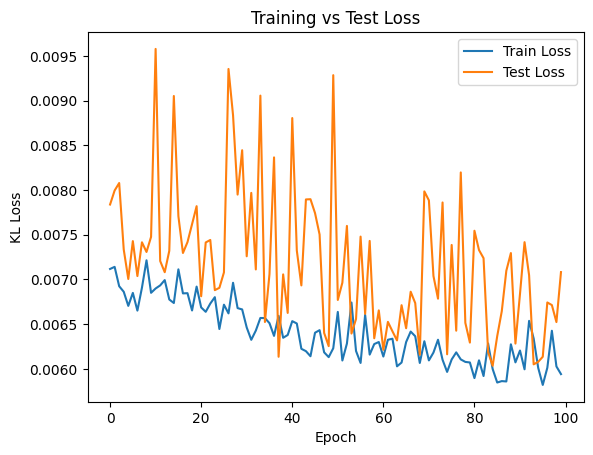

In [25]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("KL Loss")
plt.legend()
plt.title("Training vs Test Loss")
plt.show()

In [26]:
fidelities = []
l1_errors = []

model.eval()
with torch.no_grad():
    for i in range(len(X_test)):
        x = torch.tensor(X_test[i], dtype=torch.float32).unsqueeze(0)
        pred = model(x).numpy().flatten()
        true = Y_test[i]

        fidelities.append(fidelity(true, pred))
        l1_errors.append(l1_error(true, pred))

print("Average Fidelity:", np.mean(fidelities))
print("Average L1 Error:", np.mean(l1_errors))

Average Fidelity: 0.995867684368756
Average L1 Error: 0.06810328054328443


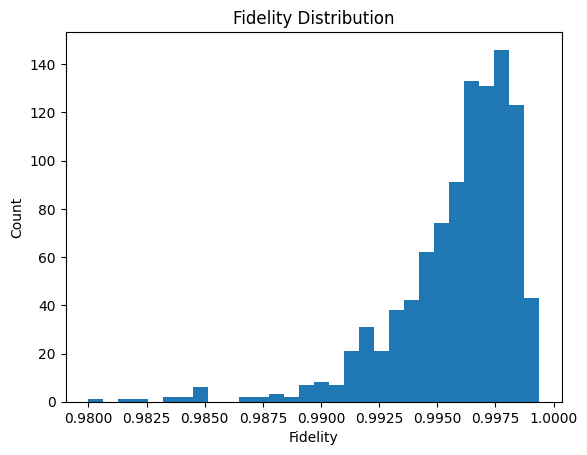

In [27]:
plt.hist(fidelities, bins=30)
plt.title("Fidelity Distribution")
plt.xlabel("Fidelity")
plt.ylabel("Count")
plt.show()

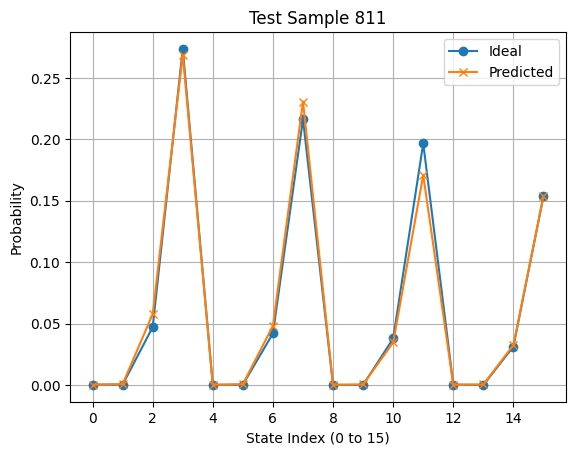

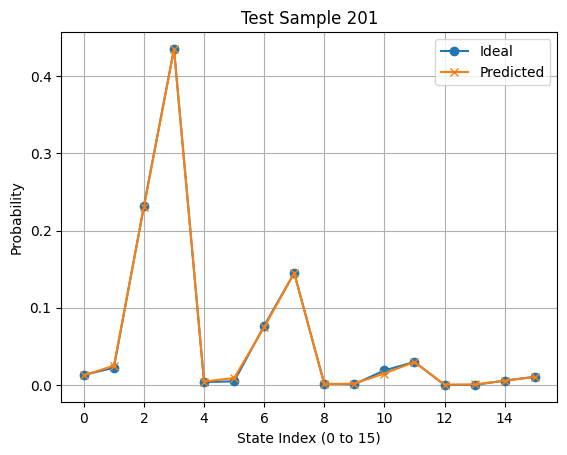

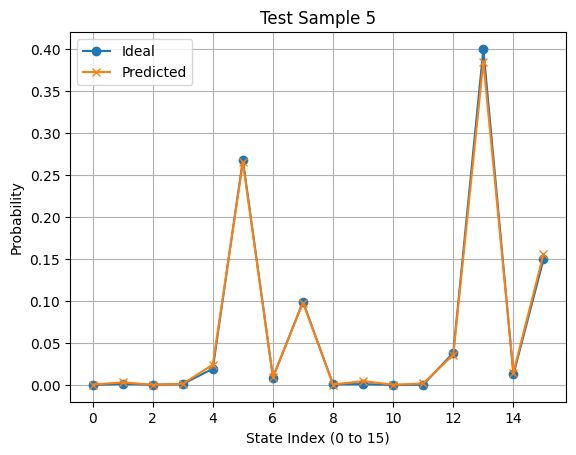

In [29]:
import numpy as np

model.eval()

num_samples_to_plot = 3
indices = np.random.choice(len(X_test), num_samples_to_plot, replace=False)

with torch.no_grad():
    for idx in indices:
        
        x = torch.tensor(X_test[idx], dtype=torch.float32).unsqueeze(0)
        pred = model(x).numpy().flatten()
        true = Y_test[idx]

        plt.figure()
        plt.plot(true, label="Ideal", marker='o')
        plt.plot(pred, label="Predicted", marker='x')
        plt.title(f"Test Sample {idx}")
        plt.xlabel("State Index (0 to 15)")
        plt.ylabel("Probability")
        plt.legend()
        plt.grid()
        plt.show()